In [13]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset
# Load the dataset
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Data Cleaning
df["job_posted_date"]=pd.to_datetime(df["job_posted_date"])
df["job_skills"]=df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

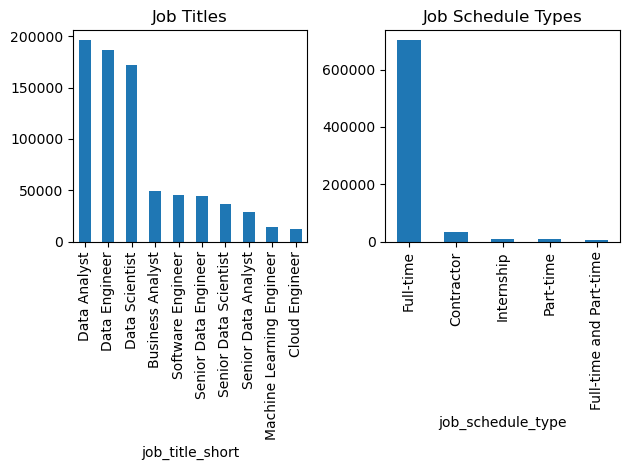

In [14]:
fig, ax = plt.subplots(1,2)

df['job_title_short'].value_counts().plot(kind='bar', ax=ax[0])
df['job_schedule_type'].value_counts().head(5).plot(kind='bar', ax=ax[1])
ax[0].set_title("Job Titles")
ax[1].set_title("Job Schedule Types")
plt.tight_layout()

#Example Count of Top Skills in Job Postings
-----------------------------------------



In [15]:
df_skills = df.copy()

df_skills = df_skills.explode('job_skills')

skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()

df_skills_count = skills_count.reset_index(name='skill_count')

df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)



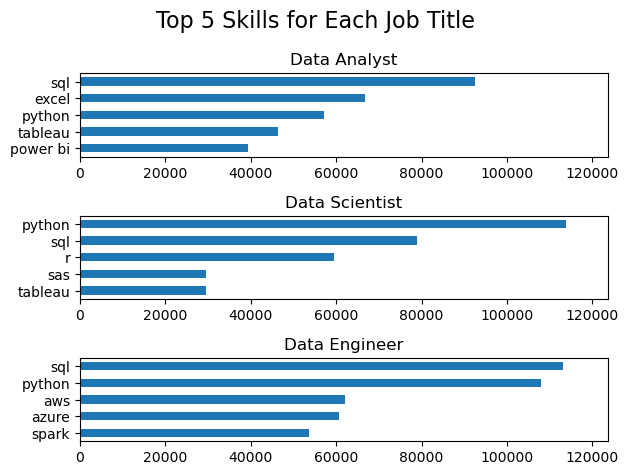

In [16]:
job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']

last= df_skills_count['skill_count'].max()

fa, ax = plt.subplots(3,1)

for i, jobs in enumerate(job_titles):
    df_job = df_skills_count[df_skills_count['job_title_short'] == jobs].head(5)
    df_job.plot(kind='barh', x='job_skills', y='skill_count', ax=ax[i], legend=False)
    ax[i].set_title(jobs)
    ax[i].invert_yaxis()
    ax[i].set_ylabel("")
    ax[i].set_xlim(0, last + 10000)

plt.suptitle("Top 5 Skills for Each Job Title", fontsize=16)
plt.tight_layout()